In [1]:
import time
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image
import math

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

from network.layer import Layer,WriteConfig

In [2]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=10,adc_last_gap=10)
chip.clk_manager.set_cyc(20,100)
chip.add_compiler("./code/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 52136
正在编译文件:  ./code/read_point3.txt
正在编译文件:  ./code/read_point3_col.txt
正在编译文件:  ./code/row_read_point3.txt
正在编译文件:  ./code/set_reset.txt
正在编译文件:  ./code/write_verify.txt
正在编译文件:  ./code/汇编测试代码.txt
正在编译文件:  ./code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ./code/读单点测试.txt


In [346]:
# 两个100个元素的列表
good_device = np.load("./data/good_point_100_100_1_4.npy")
# 100*2的矩阵,转置后变成2*100
params = np.load("./data/hnn_sum_to_add_fit_1_4.npy")
line_resistance=np.load("./data/20line_resistance_1_4.npy")
cond_reference = 550
weight_min,weight_max = -0.17,0.17

state_flat = np.load("./data/image0.npy").reshape(1,100)

# 并行计算,多行并行输出
col_index = good_device[1][np.where(state_flat < 0)[1]]
# col_index = good_device[1][:80]
col_nums = len(col_index)
print(col_nums)
interval = 20
nums = math.ceil(col_nums/interval)


v_cond_pos = np.zeros((100,1))
for i in range(nums):
    col_num = min((i+1)*interval,col_nums)-i*interval-1
    gain = 1 if col_num<=10 else 3
    voltage_base = chip.read_chunk_parallel2(row_index=[good_device[0]],col_index=[col_index[i*interval:(i+1)*interval]],read_voltage=0,tg=5,gain=gain,from_row=False,out_type=0,compute=True
                                    ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                    )[good_device[0],:]
    voltage = chip.read_chunk_parallel2(row_index=[good_device[0]],col_index=[col_index[i*interval:(i+1)*interval]],read_voltage=0.1,tg=5,gain=gain, from_row=False,out_type=0,compute=True
                                    ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                    )[good_device[0],:]

    cond = chip.voltage_to_cond(voltage-voltage_base)
    v_cond_pos += cond/(1-cond*line_resistance[:,col_num:col_num+1])

v_cond_pos1 = np.zeros((100,1))
for i in range(nums):
    col_num = min((i+1)*interval,col_nums)-i*interval-1
    gain = 1 if col_num<=10 else 3
    need_read = np.zeros((256,256),dtype=bool)
    weight_pos = np.ix_(good_device[0], col_index[i*interval:(i+1)*interval])
    need_read[weight_pos] = True

    voltage_base=chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=False,out_type=0)
    voltage=chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=False,out_type=0)
    cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[good_device[0],:]
    v_cond_pos1 += cond/(1-cond*line_resistance[:,col_num:col_num+1])



need_read = np.zeros((256,256),dtype=bool)
weight_pos = np.ix_(good_device[0], col_index)
need_read[weight_pos] = True
voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=False,out_type=0)
voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=False,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[weight_pos]
cond =np.sum(cond,axis=1)


for i in range(100):
    # print(v_cond_pos[i],v_cond_pos1[i])
    print(v_cond_pos[i]-cond[i],cond[i],v_cond_pos1[i]-cond[i])

84
[939.21188269] 50575.20541036245 [442.73534313]
[-1995.94994602] 49141.824361763494 [-1575.77615473]
[-2213.53405162] 50331.71744341468 [-1689.69007804]
[-571.66063952] 49224.46462102666 [-963.58133658]
[-2063.76367097] 49174.75381373043 [-1611.67170292]
[-982.96425909] 49199.76753205147 [-968.41630082]
[-2249.32637939] 50313.036312010365 [-1721.44061512]
[-966.45166319] 49698.77538108878 [-824.77477341]
[-2141.27465741] 49842.841733444104 [-1627.45644878]
[-938.35221158] 49373.28041356952 [-705.2576836]
[-1110.94897928] 48944.880908653584 [-742.24571651]
[-1286.40883019] 49067.416465492075 [-854.76220504]
[-2239.06264767] 50193.03378993856 [-1752.09938008]
[-1451.17958428] 50099.31150357115 [-970.08598067]
[-2154.72236966] 48840.07659518192 [-1644.40953817]
[-1275.05735779] 48895.80336004904 [-845.51590416]
[-2265.70833559] 49433.43998927834 [-1758.02939005]
[-2231.19647504] 48418.32630652856 [-1706.6073035]
[-1444.09839475] 50265.85853948081 [-999.55297405]
[-2787.01684735] 49295.

In [4]:
cond_min,cond_max,cond_reference = 0,1100,550
cond_range = cond_max-cond_reference
weight_min,weight_max = -0.17,0.17
line_resistance=np.load("./data/20line_resistance_1_4.npy")
def forward_unsigned_from_col(row_index,col_index,forward_type=1):
    """
        这里是从列给信号行读,每次最多并行10列,所以增益用1挡
    """
    col_nums = len(col_index)
    row_nums = len(row_index)
    interval = 10
    if col_nums <= 0:
        return np.zeros((len(row_index),1))
    
    if forward_type==1:
        nums = math.ceil(col_nums/interval)
        
        cond_add = np.zeros((row_nums,1))
        for i in range(nums):
            need_read = np.zeros((256,256),dtype=bool)
            col_num = min((i+1)*interval,col_nums)-i*interval
            gain = 1 if col_num<=10 else 3
            weight_pos = np.ix_(row_index, col_index[i*interval:(i+1)*interval])
            need_read[weight_pos] = True

            voltage_base=chip.compute(crossbar=need_read,read_voltage=0,tg=5,gain=gain,from_row=False,out_type=0)
            voltage=chip.compute(crossbar=need_read,read_voltage=0.1,tg=5,gain=gain,from_row=False,out_type=0)
            cond_sum = chip.voltage_to_cond(voltage=voltage-voltage_base)[row_index,:]
            # 返回的是100*1的np矩阵
            cond_add += cond_sum/(1-cond_sum*line_resistance[:,col_num-1:col_num])-col_num*cond_reference

        return (cond_add/cond_range*weight_max).flatten()
    elif forward_type==2:
        nums = math.ceil(col_nums/interval)
        cond_add = np.zeros((row_nums,1))
        for i in range(nums):
            col_num = min((i+1)*interval,col_nums)-i*interval
            gain = 1 if col_num<=10 else 3
            voltage_base = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index[i*interval:(i+1)*interval]],read_voltage=0,tg=5,gain=gain,
                                                     from_row=False,out_type=0,compute=True
                                                    ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                                    )[row_index,:]
            voltage = chip.read_chunk_parallel2(row_index=[row_index],col_index=[col_index[i*interval:(i+1)*interval]],read_voltage=0.1,tg=5,gain=gain, 
                                                from_row=False,out_type=0,compute=True
                                                ,tia_split=[0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3]
                                                )[row_index,:]

            cond_sum = chip.voltage_to_cond(voltage-voltage_base)
            cond_add += cond_sum/(1-cond_sum*line_resistance[:,col_num-1:col_num])-col_num*cond_reference
        return (cond_add/cond_range*weight_max).flatten()
    elif forward_type==3:
        need_read = np.zeros((256,256),dtype=bool)
        weight_pos = np.ix_(row_index, col_index)
        need_read[weight_pos] = True
        voltage_base = chip.read_point2(crossbar=need_read,read_voltage=0,tg=5,gain=1,from_row=False,out_type=0)
        voltage = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=1,from_row=False,out_type=0)
        cond = chip.voltage_to_cond(voltage=voltage-voltage_base)[weight_pos]-cond_reference
        cond =np.sum(cond,axis=1)

        return (cond/cond_range*weight_max).flatten()
    

In [5]:
# 两个100个元素的列表
good_device = np.load("./data/good_point_100_100_1_4.npy")
def forward(state_flat:np.ndarray):
    """
        state_flat:为1*100的np数组
        split_type = 0,就是采用
    """
    state_flat_new = state_flat.reshape(1,100)
    
    col_index = good_device[1][np.where(state_flat_new > 0)[1]]
    value_pos = forward_unsigned_from_col(good_device[0],col_index,forward_type=2)
    

    col_index = good_device[1][np.where(state_flat_new < 0)[1]]
    value_neg = forward_unsigned_from_col(good_device[0],col_index,forward_type=2)

    return value_pos-value_neg

In [6]:
# # 两个100个元素的列表
# good_device = np.load("./data/good_point_100_100_1_4.npy")
# # 100*2的矩阵,转置后变成2*100
# params = np.load("./data/hnn_sum_to_add_fit_1_4.npy").T
# cond_reference = 550
# weight_min,weight_max = -0.17,0.17
# def forward(state_flat:np.ndarray):
#     """
#         state_flat:为1*100的np数组
#         split_type = 0,就是采用
#     """
#     state_flat_new = state_flat.reshape(1,100)
    

#     col_index = good_device[1][np.where(state_flat_new > 0)[1]]

#     if len(col_index)>0:
#         v_base = chip.read_chunk_parallel2(row_index=[good_device[0]],col_index=[col_index],read_voltage=0,tg=5,gain=3,from_row=False,out_type=0,compute=True)[good_device[0],:]
#         v_pos = chip.read_chunk_parallel2(row_index=[good_device[0]],col_index=[col_index],read_voltage=0.1,tg=5,gain=3, from_row=False,out_type=0,compute=True)[good_device[0],:]

#         col_nums = len(col_index)
#         v_cond_pos = chip.voltage_to_cond(v_pos-v_base)*(col_nums*params[0,:]+params[1,:]).reshape(100,1)
#         print("2222",v_cond_pos.shape)
#         v_cond_pos-= col_nums*cond_reference

#     else:
#         v_cond_pos = np.zeros((100,1))
    

#     col_index = good_device[1][np.where(state_flat_new < 0)[1]]
#     if len(col_index)>0:
#         v_base = chip.read_chunk_parallel2(row_index=[good_device[0]],col_index=[col_index],read_voltage=0,tg=5,gain=3,from_row=False,out_type=0,compute=True)[good_device[0],:]
#         v_neg = chip.read_chunk_parallel2(row_index=[good_device[0]],col_index=[col_index],read_voltage=0.1,tg=5,gain=3,from_row=False,out_type=0,compute=True)[good_device[0],:]
        
#         col_nums = len(col_index)
#         v_cond_neg = chip.voltage_to_cond(v_neg-v_base)*(col_nums*params[0,:]+params[1,:]).reshape(100,1)
#         v_cond_neg-= col_nums*cond_reference
#     else:
#         v_cond_neg = np.zeros_like(v_cond_pos)

#     v_cond = v_cond_pos - v_cond_neg
#     ans = (v_cond/cond_reference*weight_max).flatten()
#     return ans

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from skimage.transform import resize

In [10]:
steps = 10

(100,)
(100,)
(100,)
(100,)
(100,)


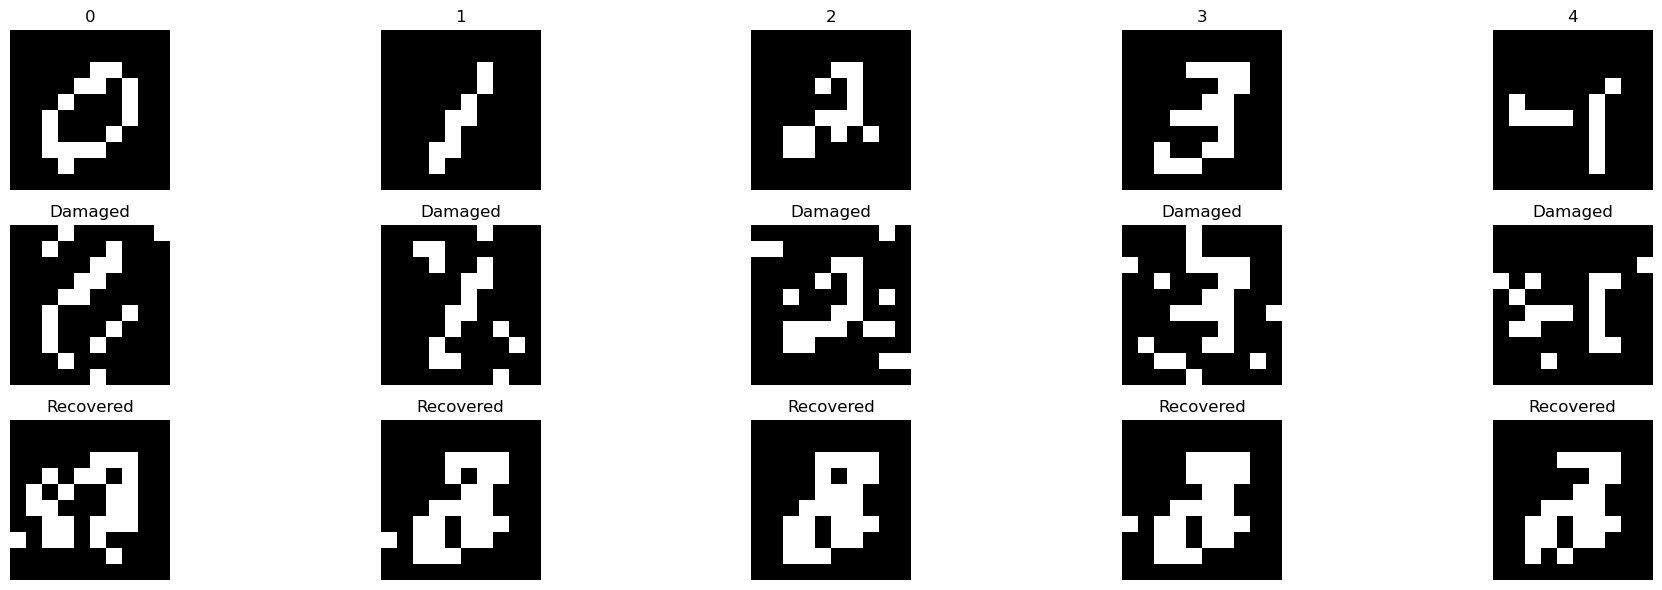

In [11]:

# -----------------------------
# 可调参数：网络总神经元数量（必须为完全平方数，如100、400、784等）
net_size = 100  # 例如 100 表示 10×10
num_imgs = 5
side = int(np.sqrt(net_size))  # 图像边长

# -----------------------------
# 1. 加载 MNIST 数据，选取数字 0～9 各一张图
(train_images, train_labels), _ = mnist.load_data()

selected_patterns = []
for digit in range(num_imgs):
    idx = np.where(train_labels == digit)[0][0]
    img = train_images[idx]
    selected_patterns.append(img)


# 2. 定义预处理函数：缩放 + 二值化
def preprocess_image(img, side, threshold=128):
    """
    缩放原始图像到 side x side，并二值化（像素值 > threshold 记为 +1，其它记为 -1）
    """
    # 缩放图像到 side x side（返回浮点型，值在0-1之间）
    img_resized = resize(img, (side, side), anti_aliasing=True)
    # 还原到0-255范围
    img_resized = img_resized * 255
    # 二值化
    bin_img = np.where(img_resized > threshold, 1, -1)
    return bin_img


# 对选取的图像进行预处理
processed_patterns = [preprocess_image(p, side) for p in selected_patterns]

# -----------------------------
# 4. 定义异步更新函数（回忆过程）
def hopfield_recall(state, W, steps=10000):
    """
    state: 初始状态（side x side，取值 +1/-1）
    W: 训练好的权重矩阵
    steps: 更新次数上限
    返回: 收敛后的状态（side x side）
    """
    state_flat = state.flatten()
    N = state_flat.size
    for _ in range(steps):
        i = np.random.randint(0, N)  # 随机选择一个神经元
        h_i = np.dot(W[i, :], state_flat)
        state_flat[i] = 1 if h_i >= 0 else -1
    return state_flat.reshape((side, side))


def hopfield_recall_sync(state, W, steps=10000):
    """
    state: 初始状态（side x side，取值 +1 或 -1）
    W: 训练好的权重矩阵
    steps: 最大更新次数
    返回: 收敛后的状态（side x side）

    采用同步更新：每一步计算所有神经元的新状态，然后同时更新
    """
    state_flat = state.flatten()
    print(state_flat.shape)
    for _ in range(steps):
        # 同步计算所有神经元的净输入并更新状态
        new_state = np.where(forward(state_flat) >= 0, 1, -1)
        # new_state = np.where(np.dot(W, state_flat) >= 0, 1, -1)
        # 如果新状态与旧状态相同，则认为已收敛，退出循环
        if np.array_equal(new_state, state_flat):
            break
        state_flat = new_state
    return state_flat.reshape((state.shape))


import numpy as np

# -----------------------------
# 5. 定义损坏函数（随机翻转像素）
def damage_pattern(pattern, damage_rate=0.3):
    """
    随机翻转一定比例 (damage_rate) 的像素
    """
    damaged = pattern.copy().flatten()
    N = damaged.size
    num_flip = int(damage_rate * N)
    flip_indices = np.random.choice(N, num_flip, replace=False)
    damaged[flip_indices] *= -1
    return damaged.reshape((side, side))


# -----------------------------
# 6. 对每个数字测试：破坏后用 Hopfield 网络回忆
recovered_patterns = []
damaged_patterns = []
damage_rate = 0.1 # 例如翻转 30% 像素

W = 0
for p in processed_patterns:
    damaged = damage_pattern(p, damage_rate)
    recovered = hopfield_recall_sync(damaged, W, steps=steps)
    damaged_patterns.append(damaged)
    recovered_patterns.append(recovered)

# -----------------------------
# 7. 可视化展示原始、损坏与回忆后的图像
# fig, axes = plt.subplots(num_imgs, 3, figsize=(8, 25))
# for i in range(num_imgs):
#     axes[i, 0].imshow(processed_patterns[i], cmap='gray', vmin=-1, vmax=1)
#     axes[i, 0].set_title(f"origin {i}")
#     axes[i, 0].axis('off')

#     axes[i, 1].imshow(damaged_patterns[i], cmap='gray', vmin=-1, vmax=1)
#     axes[i, 1].set_title("10% damage")
#     axes[i, 1].axis('off')

#     axes[i, 2].imshow(recovered_patterns[i], cmap='gray', vmin=-1, vmax=1)
#     axes[i, 2].set_title("result")
#     axes[i, 2].axis('off')

# plt.tight_layout()
# plt.show()

fig, axes = plt.subplots(3, num_imgs, figsize=(20, 6))
for i in range(num_imgs):
    # 第一行：原始图像
    axes[0, i].imshow(processed_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].set_title(f"{i}")
    axes[0, i].axis('off')

    # 第二行：损坏图像
    axes[1, i].imshow(damaged_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].set_title("Damaged")
    axes[1, i].axis('off')

    # 第三行：回忆结果
    axes[2, i].imshow(recovered_patterns[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].set_title("Recovered")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
for p in processed_patterns:
    print(p.flatten())
np.save("./data/image0.npy",processed_patterns[0].flatten())

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1  1  1 -1 -1 -1 -1 -1 -1 -1  1  1 -1  1 -1 -1 -1 -1 -1  1 -1 -1 -1  1
 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1 -1 -1
  1  1  1  1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1
 -1 -1 -1 -1 -1 -1  1  1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1
 -1  1  1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1  1  1 -1 -1 -1 -1 -1 -1 -1  1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1
 -1 -1 -1 -1 -1 -1  1  1  1 -1 -1 -1 -1 -1  1  1 -1  1 -1  1 -1 -1 -1 -1
  1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1]
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  1  1  1